In [170]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Thu Jul 18 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

In [171]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [115]:
with open('/home/yaning/Documents/Discounting/results/array_cafe_gamble.pkl', 'rb') as f:
    data = pickle.load(f)

In [172]:
with open('/home/yaning/Documents/Discounting/results/array_future.pkl', 'rb') as f:
    data = pickle.load(f)

In [11]:
with open('/home/yaning/Documents/Discounting/results/array_buhui.pkl', 'rb') as f:
    data = pickle.load(f)

In [173]:
data = data[1]

In [174]:
data = torch.tensor(data)

In [175]:
data = data.to(device)

In [163]:
data.shape

torch.Size([30, 118, 6])

In [25]:
data = data.reshape(60,170,8)

In [176]:
def model(data):
    num_params = 4
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        sigma_rate = torch.exp(locs[:,0]).unsqueeze(-1).expand(-1, num_trials)
        a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        b = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)
        # tan_a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        # tan_b = locs[:,2].unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,3]).unsqueeze(-1).expand(-1, num_trials)

        sigma_combine = sigma_rate/(1+b*torch.exp(-a*data[:,:,2]))
        # sigma_combine = sigma_rate
        # sigma_combine = sigma_rate*torch.log(data[:,:,2]*ln_a + 1)
        # sigma_combine = sigma_rate*(torch.tanh(tan_a*data[:,:,2] + tan_b) + 1)

        e_mean = (data[:,:,3])/(1 + sigma_combine**2)

        # e_mean = (data[:,:,3])/(sigma_combine + 1)
        sum = e_mean + torch.tensor(20., device=device)
        # p_ll = e_mean/sum
        # p_ss = torch.tensor(20.)/sum
        # p = p_ll**beta/(p_ll**beta + p_ss**beta)

        softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [177]:
def guide(data):
    num_params = 4
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 871.26: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:47<00:00, 105.39it/s]


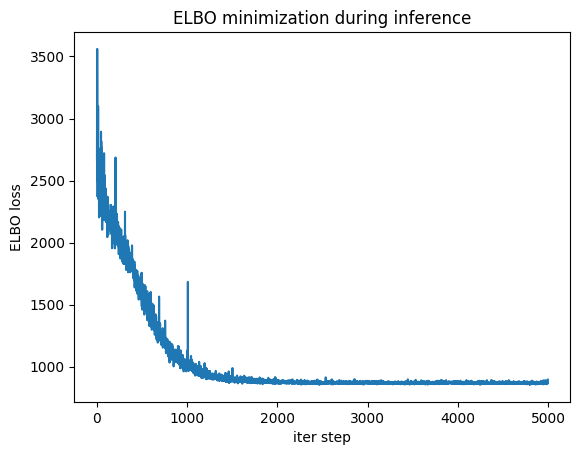

In [178]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [29]:
for i in loss:
    print(i.numpy())

6568.51
7207.5547
7258.491
7000.5083
6548.909
8339.902
7104.8115
6928.796
6978.181
7501.6807
7367.3745
6453.1436
8508.223
7508.2197
7048.9575
6762.678
6878.567
7092.6616
6912.2617
7575.2534
6820.4824
6974.6147
7059.6353
6908.564
6276.604
6362.3667
6732.259
7046.661
6555.7646
6816.4995
6372.4043
6888.8037
6847.313
6378.6484
6582.905
7031.2417
6843.896
6735.0874
6658.5645
6490.861
6755.9487
6608.7656
6484.227
6492.0356
6901.8335
6397.163
7157.5107
6507.45
6519.4487
6451.6626
6756.928
6617.4077
6655.827
6459.949
6547.8447
6255.541
6775.4614
6406.3555
6702.988
6530.867
6418.133
6741.3647
6646.508
6485.2983
6398.3096
6304.7603
6458.027
6380.562
6430.669
6483.5557
5999.8975
6378.796
6565.3604
6368.2485
6277.4424
6566.6855
6246.3037
6025.337
6487.0845
6591.196
6260.158
6466.7725
6087.029
6976.0894
6366.372
6135.6045
6294.8945
6558.7314
6444.816
6238.965
6142.7876
5967.6626
6217.074
6233.3633
6189.183
6309.6304
6287.299
6171.226
6098.476
6070.353
6065.04
6469.443
6273.261
6285.8955
6091.6904
6

In [53]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [12]:
#no future
numpy_dict["m"]

array([ 0.7418972, -0.3072213,  1.5078298,  2.4903939], dtype=float32)

In [13]:
#future
numpy_dict["m_locs"].shape

(30, 4)

In [120]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [121]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'arctan_a', 'arctan_b', 'beta'])

In [122]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_indiv.csv", index=False)

In [123]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/arctan_mean.csv", index=False)

In [38]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/gamble.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)

In [39]:
numpy_dict["m"]

array([0.9563904, 0.0258028, 1.4622841, 2.4189122], dtype=float32)

In [179]:
sample_num = 1000
tau = []
mu = []
locs = []
for i in range(sample_num):
    tau.append(guide(data)['tau'].detach().cpu().numpy())
    mu.append(guide(data)['mu'].detach().cpu().numpy())
    locs.append(guide(data)['locs'].detach().cpu().numpy())

In [126]:
test = np.array(locs)

In [127]:
test.shape

(1000, 30, 4)

In [128]:
test = np.mean(test, axis=1)

In [129]:
for i in test:
    print(i[0])

0.90521485
1.011483
0.86753494
0.9885114
0.9533513
0.9041043
1.0306097
0.97303414
0.9760908
1.0338391
1.007498
0.96037537
0.951749
0.98167616
0.9809807
0.98839563
0.99567235
1.0398912
0.9563754
1.0082976
0.9681644
0.9959187
0.96521455
0.9680243
1.0397848
0.9695323
0.97411025
0.9841425
0.96618575
0.9364928
0.9682299
0.9422678
0.9963829
0.95496327
0.90110403
1.0086159
0.93979245
0.9806183
0.9403168
0.9270569
0.9561585
0.9298839
1.0127796
0.92979205
0.9855471
0.98069
0.9877357
0.9299739
0.9905402
0.89354074
0.97059095
0.9611634
0.9909063
0.94681704
1.0028156
0.9748038
0.95707047
0.91222256
0.8991931
0.9992205
0.98138624
0.9808584
1.0029217
0.95502347
0.9464109
0.8951466
0.91327494
0.9830027
0.930194
0.94982255
0.9751888
1.0216663
0.9874163
1.0126072
1.0013642
0.9738022
1.026811
0.9224155
0.9705773
1.0215783
0.9425973
0.9920881
0.953739
1.040069
1.0130022
1.0155419
0.96170384
0.94133925
1.0200608
0.99488384
0.938297
0.9975193
0.9784667
0.9790322
0.94911295
0.98525006
0.98298657
0.9499294
0

In [180]:
sample_dict = {
    'tau': tau,
    'mu': mu,
    'locs': locs
}

In [181]:
with open('/home/yaning/Documents/Discounting/paper/results/future_1_samples.pkl', 'wb') as f:
    pickle.dump(sample_dict, f)

In [82]:
locs[0].shape

(60, 2)

In [30]:
data.shape

torch.Size([60, 170, 8])

In [33]:
locs[0].device

'cpu'

In [83]:
probs = []
for i in locs:
    sigma_rate = torch.tensor(i[:,0]).unsqueeze(-1).to(device)
    # a = torch.tensor(i[:,1]).unsqueeze(-1).to(device)
    # b = torch.tensor(i[:,1]).unsqueeze(-1).to(device)
    beta = torch.tensor(i[:,1]).unsqueeze(-1).to(device)

    sigma_rate = torch.exp(sigma_rate)
    # a = torch.exp(a)
    # b = torch.exp(b)
    beta = torch.exp(beta)

    # sigma_combine = sigma_rate/(1+b*torch.exp(-data[:,:,2]))
    sigma_combine = sigma_rate
    # sigma_combine = sigma_rate*(torch.tanh(a*data[:,:,2] + b) + 1)

    e_mean = (data[:,:,3])/(1 + sigma_combine**2)

    # e_mean = (data[:,:,3])/(sigma_combine + 1)
    sum = e_mean + torch.tensor(20., device=device)
    # p_ll = e_mean/sum
    # p_ss = torch.tensor(20.)/sum
    # p = p_ll**beta/(p_ll**beta + p_ss**beta)

    softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
    p = torch.softmax(softmax_args, dim = 0)[0]
    probs.append(p)

In [84]:
probs[0].shape

torch.Size([60, 170])

In [92]:
data[:,:,4].shape

torch.Size([60, 170])

In [85]:
likeli = []
for i in probs:
    temp = i*data[:,:,4] + (1-data[:,:,4])*(1-i)
    temp = temp.cpu()
    likeli.append(temp)

In [86]:
len(likeli)

1000

In [69]:
likeli[0].shape

torch.Size([60, 170])

In [87]:
likeli = np.array(likeli)

In [88]:
likeli.shape

(1000, 60, 170)

In [89]:
data.shape

torch.Size([60, 170, 8])

In [89]:
final = likeli.reshape(10200, 1000)

In [73]:
final.shape

(10200, 1000)

In [101]:
final

array([[0.87759072, 0.76903937, 0.72187691, ..., 0.96828495, 0.51933621,
        0.91286518],
       [0.63630422, 0.63317475, 0.9174833 , ..., 0.97450107, 0.10077971,
        0.5803971 ],
       [0.80010696, 0.43951311, 0.92946544, ..., 0.82998965, 0.9753235 ,
        0.42373076],
       ...,
       [0.99999982, 1.        , 1.        , ..., 0.93802503, 0.99610177,
        0.22152197],
       [0.99371881, 0.93656727, 0.97289571, ..., 0.45798121, 0.51097907,
        0.98003825],
       [0.98578655, 0.97258737, 0.98686767, ..., 0.22709846, 0.86794435,
        0.8508115 ]])

In [90]:
final = torch.tensor(final)

In [91]:
torch.isnan(final).any()

tensor(False)

Single model WAIC value

In [ ]:
log_likes = torch.log(final)

lppd = torch.logsumexp(log_likes, dim=-1) - torch.log(torch.tensor(1000))
lppd = lppd.sum(dim=0)

p_waic = log_likes.var(dim=-1, unbiased=True).sum(dim=0)

waic = -2 * (lppd - p_waic)

Compare

In [92]:
log_likes = torch.log(final)

lppd = torch.logsumexp(log_likes, dim=-1) - torch.log(torch.tensor(1000))
# lppd = lppd.sum(dim=0)

p_waic = log_likes.var(dim=-1, unbiased=True)

waic_square = -2 * (lppd - p_waic)

In [93]:
dict = {
    'square': waic_square,
    'three': waic_three,
    'four': waic_four,
    'tan': waic_tan
}

In [ ]:
# with open('/home/yaning/Documents/Discounting/paper/results/waic_all_models.pkl', 'wb') as f:
#     pickle.dump(dict, f)

In [30]:
with open('/home/yaning/Documents/Discounting/paper/results/waic_all_models.pkl', 'rb') as f:
    dict = pickle.load(f)

In [34]:
dict.keys()

dict_keys(['square', 'three', 'four', 'tan'])

In [31]:
waic_three = dict["three"]

In [35]:
waic_four = dict["four"]

In [32]:
waic_tan = dict["tan"]

In [33]:
waic_square = dict["square"]

In [41]:
delta_waic = waic_three - waic_tan

In [42]:
delta_waic.sum()

tensor(147.1538, dtype=torch.float64)

In [43]:
torch.sqrt(10200 * delta_waic.var(unbiased=True))

tensor(9.0334, dtype=torch.float64)

In [48]:
for i in waic_square:
    print(i.item())

1.2832094324742265
1.2415995554845187
1.1629714270227076
1.3153749954156981
1.3058502655678583
1.2484338972580802
1.202279153165727
1.087039694690434
1.3501392057522819
1.3247140284106158
1.3253272235456417
1.2148823549884948
1.21160522209441
1.282008882011811
1.2995422203464924
1.311508318388084
1.0199063807219662
1.3702715759498822
1.383991931880975
1.2410196506972189
1.294193862430901
1.2226287553546922
1.270391382781555
1.2630074196208811
1.287411171686991
1.3659122467626046
1.1133661879762722
1.1218595119391412
1.2773152185233383
1.2447189100433074
1.3739413430477012
1.2823243452743547
1.2260232968408256
1.1333801604149383
1.297131970533309
1.4038376343232821
1.1728938708036227
1.144007282023552
1.2363208958220244
1.2761690660865361
1.4269178635290265
1.5217363088542255
1.400601545095584
1.1528840375477734
1.3032262912078685
1.3585671377681539
1.2647421044918
1.0362599536934043
1.2241895704863133
1.3163901709880415
1.3985919393346888
1.200265935663866
1.3071308636053096
1.15729587